In [1]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import os
import random
import time
import copy
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader,
    random_split
)

from torchvision import datasets, transforms
from torchvision.models import (
    resnet18,
    mobilenet_v3_small,
    efficientnet_b0,
    convnext_tiny
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tqdm.auto import tqdm

print("Imports completed successfully.")

Imports completed successfully.


c:\Users\cscpr\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# CELL 2 — REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Makes experiments more reproducible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed:", SEED)

Random seed: 42


In [3]:
# ============================================================
# CELL 3 — GPU CONFIGURATION
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("COMPUTE CONFIGURATION")
print("=" * 60)

print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())
print("Device          :", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU             :",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA Version    :",
        torch.version.cuda
    )

    gpu_memory = (
        torch.cuda.get_device_properties(0)
        .total_memory / (1024 ** 3)
    )

    print(
        f"GPU Memory      : {gpu_memory:.2f} GB"
    )

else:

    raise RuntimeError(
        "CUDA GPU is not available."
    )

print("=" * 60)

COMPUTE CONFIGURATION
PyTorch Version : 2.13.0+cu132
CUDA Available  : True
Device          : cuda
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU
CUDA Version    : 13.2
GPU Memory      : 6.00 GB


In [4]:
# ============================================================
# CELL 4 — PROJECT PATHS
# ============================================================

DATASET_PATH = r"C:\Users\cscpr\Downloads\AMSFNet\working\EuroSAT"

PROJECT_PATH = r"C:\Users\cscpr\Downloads\AMSFNet\working"

CHECKPOINT_DIR = os.path.join(
    PROJECT_PATH,
    "checkpoints"
)

RESULTS_DIR = os.path.join(
    PROJECT_PATH,
    "results"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

print("Dataset:", DATASET_PATH)
print("Checkpoints:", CHECKPOINT_DIR)
print("Results:", RESULTS_DIR)

Dataset: C:\Users\cscpr\Downloads\AMSFNet\working\EuroSAT
Checkpoints: C:\Users\cscpr\Downloads\AMSFNet\working\checkpoints
Results: C:\Users\cscpr\Downloads\AMSFNet\working\results


In [5]:
# ============================================================
# CELL 5 — DATASET VERIFICATION
# ============================================================

if not os.path.exists(DATASET_PATH):

    raise FileNotFoundError(
        f"Dataset not found:\n{DATASET_PATH}"
    )

class_folders = sorted([
    folder
    for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(
        os.path.join(DATASET_PATH, folder)
    )
])

print("Number of classes:", len(class_folders))

print("\nClasses:")

for i, cls in enumerate(class_folders):
    print(f"{i:2d} : {cls}")

Number of classes: 10

Classes:
 0 : AnnualCrop
 1 : Forest
 2 : HerbaceousVegetation
 3 : Highway
 4 : Industrial
 5 : Pasture
 6 : PermanentCrop
 7 : Residential
 8 : River
 9 : SeaLake


In [6]:
# ============================================================
# CELL 6 — DATASET STATISTICS
# ============================================================

dataset_raw = datasets.ImageFolder(
    DATASET_PATH
)

print("=" * 60)

print("Total images:", len(dataset_raw))

print("Number of classes:", len(dataset_raw.classes))

print("\nClass distribution:")

class_counts = {}

for _, class_index in dataset_raw.samples:

    class_name = dataset_raw.classes[class_index]

    class_counts[class_name] = (
        class_counts.get(class_name, 0) + 1
    )

for cls, count in class_counts.items():

    print(
        f"{cls:25s}: {count}"
    )

print("=" * 60)

Total images: 27000
Number of classes: 10

Class distribution:
AnnualCrop               : 3000
Forest                   : 3000
HerbaceousVegetation     : 3000
Highway                  : 2500
Industrial               : 2500
Pasture                  : 2000
PermanentCrop            : 2500
Residential              : 3000
River                    : 2500
SeaLake                  : 3000


In [7]:
# ============================================================
# CELL 7 — CLASS INFORMATION
# ============================================================

CLASS_NAMES = dataset_raw.classes

NUM_CLASSES = len(CLASS_NAMES)

print("NUM_CLASSES:", NUM_CLASSES)

print("\nClass mapping:")

for index, name in enumerate(CLASS_NAMES):

    print(
        f"{index}: {name}"
    )

NUM_CLASSES: 10

Class mapping:
0: AnnualCrop
1: Forest
2: HerbaceousVegetation
3: Highway
4: Industrial
5: Pasture
6: PermanentCrop
7: Residential
8: River
9: SeaLake


In [8]:
# ============================================================
# CELL 8 — IMAGE CONFIGURATION
# ============================================================

IMAGE_SIZE = 64

print("Image size:", IMAGE_SIZE, "x", IMAGE_SIZE)

Image size: 64 x 64


In [9]:
# ============================================================
# CELL 9 — TRAINING CONFIGURATION
# ============================================================

BATCH_SIZE = 64

NUM_WORKERS = 0

EPOCHS = 30

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4

print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("DataLoader workers:", NUM_WORKERS)

Batch size: 64
Epochs: 30
Learning rate: 0.001
Weight decay: 0.0001
DataLoader workers: 0


In [10]:
# ============================================================
# CELL 10 — DATA AUGMENTATION
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully.")

Transforms created successfully.


In [11]:
# ============================================================
# CELL 11 — DATASET WRAPPER
# ============================================================

class EuroSATDataset(Dataset):

    def __init__(
        self,
        samples,
        classes,
        transform=None
    ):

        self.samples = samples

        self.classes = classes

        self.transform = transform


    def __len__(self):

        return len(self.samples)


    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(
            image_path
        ).convert("RGB")


        if self.transform is not None:

            image = self.transform(image)


        return image, label

In [12]:
# ============================================================
# CELL 12 — TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# Create indices
num_samples = len(dataset_raw)

indices = list(range(num_samples))

# Reproducible shuffle
generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(
    num_samples,
    generator=generator
).tolist()


train_size = int(
    0.70 * num_samples
)

val_size = int(
    0.15 * num_samples
)

test_size = (
    num_samples
    - train_size
    - val_size
)


train_indices = indices[
    :train_size
]

val_indices = indices[
    train_size:
    train_size + val_size
]

test_indices = indices[
    train_size + val_size:
]


samples = dataset_raw.samples


train_samples = [
    samples[i]
    for i in train_indices
]

val_samples = [
    samples[i]
    for i in val_indices
]

test_samples = [
    samples[i]
    for i in test_indices
]


print("=" * 60)

print("Total :", num_samples)

print("Train :", len(train_samples))

print("Val   :", len(val_samples))

print("Test  :", len(test_samples))

print("=" * 60)

Total : 27000
Train : 18900
Val   : 4050
Test  : 4050


In [13]:
# ============================================================
# CELL 13 — CREATE DATASETS
# ============================================================

train_dataset = EuroSATDataset(
    train_samples,
    CLASS_NAMES,
    transform=train_transform
)

val_dataset = EuroSATDataset(
    val_samples,
    CLASS_NAMES,
    transform=eval_transform
)

test_dataset = EuroSATDataset(
    test_samples,
    CLASS_NAMES,
    transform=eval_transform
)

print("Datasets created successfully.")

Datasets created successfully.


In [14]:
# ============================================================
# CELL 14 — DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoaders created.")

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Testing batches:",
    len(test_loader)
)

DataLoaders created.
Training batches: 296
Validation batches: 64
Testing batches: 64


In [15]:
# ============================================================
# CELL 15 — BATCH VERIFICATION
# ============================================================

images, labels = next(
    iter(train_loader)
)

print("Images:", images.shape)

print("Labels:", labels.shape)

print("Image dtype:", images.dtype)

print("Label dtype:", labels.dtype)

Images: torch.Size([64, 3, 64, 64])
Labels: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64


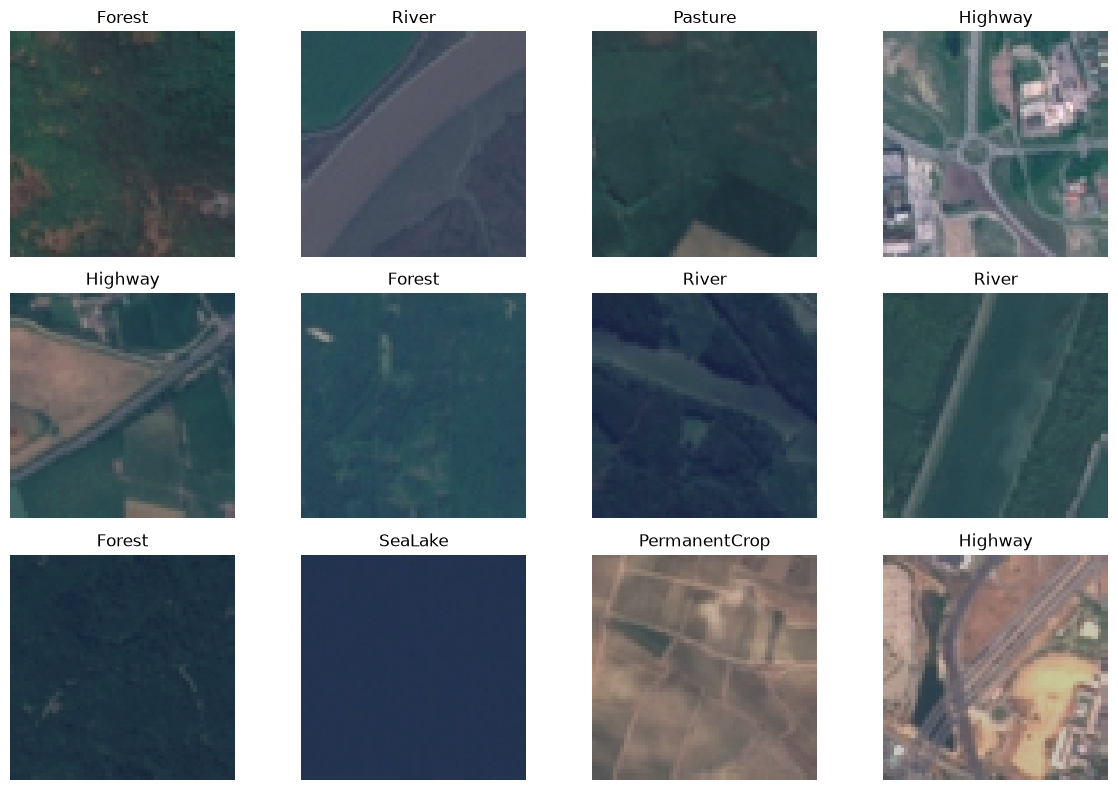

In [16]:
# ============================================================
# CELL 16 — SAMPLE VISUALIZATION
# ============================================================

def denormalize(image):

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    image = image * std + mean

    return torch.clamp(
        image,
        0,
        1
    )


plt.figure(figsize=(12, 8))

for i in range(12):

    image = denormalize(
        images[i]
    )

    image = image.permute(
        1, 2, 0
    )

    plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(image)

    plt.title(
        CLASS_NAMES[labels[i].item()]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [17]:
# ============================================================
# CELL 17 — BASELINE MODEL FACTORY
# ============================================================

def create_baseline(
    model_name,
    num_classes
):

    if model_name == "ResNet18":

        model = resnet18(
            weights=None
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )


    elif model_name == "MobileNetV3-Small":

        model = mobilenet_v3_small(
            weights=None
        )

        model.classifier[-1] = nn.Linear(
            model.classifier[-1].in_features,
            num_classes
        )


    elif model_name == "EfficientNet-B0":

        model = efficientnet_b0(
            weights=None
        )

        model.classifier[-1] = nn.Linear(
            model.classifier[-1].in_features,
            num_classes
        )


    elif model_name == "ConvNeXt-Tiny":

        model = convnext_tiny(
            weights=None
        )

        model.classifier[-1] = nn.Linear(
            model.classifier[-1].in_features,
            num_classes
        )


    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )


    return model

In [18]:
# ============================================================
# CELL 18 — BASELINE MODEL CHECK
# ============================================================

BASELINE_MODELS = [

    "ResNet18",

    "MobileNetV3-Small",

    "EfficientNet-B0",

    "ConvNeXt-Tiny"
]


for name in BASELINE_MODELS:

    temp_model = create_baseline(
        name,
        NUM_CLASSES
    )

    temp_model = temp_model.to(
        DEVICE
    )

    parameters = sum(
        p.numel()
        for p in temp_model.parameters()
        if p.requires_grad
    )

    print(
        f"{name:22s} : "
        f"{parameters / 1e6:.3f} M parameters"
    )

    del temp_model

    torch.cuda.empty_cache()

ResNet18               : 11.182 M parameters
MobileNetV3-Small      : 1.528 M parameters
EfficientNet-B0        : 4.020 M parameters
ConvNeXt-Tiny          : 27.828 M parameters


In [19]:
# ============================================================
# CELL 19 — AFIE BLOCK
# ============================================================

class AFIEBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):

        super().__init__()


        # ----------------------------------------------------
        # Local branch
        # ----------------------------------------------------

        self.local_branch = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.GELU()
        )


        # ----------------------------------------------------
        # Context branch
        # ----------------------------------------------------

        self.context_branch = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=2,
                dilation=2,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.GELU()
        )


        # ----------------------------------------------------
        # Texture branch
        # ----------------------------------------------------

        self.texture_branch = nn.Sequential(

            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                groups=in_channels,
                bias=False
            ),

            nn.BatchNorm2d(
                in_channels
            ),

            nn.GELU(),

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.GELU()
        )


        # ----------------------------------------------------
        # Importance estimator
        # ----------------------------------------------------

        hidden = max(
            out_channels // 4,
            8
        )


        self.importance_pool = (
            nn.AdaptiveAvgPool2d(1)
        )


        self.importance_estimator = nn.Sequential(

            nn.Conv2d(
                out_channels * 3,
                hidden,
                kernel_size=1
            ),

            nn.GELU(),

            nn.Conv2d(
                hidden,
                out_channels * 3,
                kernel_size=1
            )
        )


        # ----------------------------------------------------
        # Feature refinement
        # ----------------------------------------------------

        self.refinement = nn.Sequential(

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                groups=out_channels,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.GELU(),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            )
        )


        # ----------------------------------------------------
        # Shortcut
        # ----------------------------------------------------

        if (
            stride != 1
            or in_channels != out_channels
        ):

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(
                    out_channels
                )
            )

        else:

            self.shortcut = nn.Identity()


        self.activation = nn.GELU()


    def forward(self, x):

        local = self.local_branch(x)

        context = self.context_branch(x)

        texture = self.texture_branch(x)


        # [B, 3, C, H, W]

        features = torch.stack(
            [
                local,
                context,
                texture
            ],
            dim=1
        )


        combined = torch.cat(
            [
                local,
                context,
                texture
            ],
            dim=1
        )


        descriptor = self.importance_pool(
            combined
        )


        logits = self.importance_estimator(
            descriptor
        )


        logits = logits.view(
            x.size(0),
            3,
            local.size(1),
            1,
            1
        )


        weights = torch.softmax(
            logits,
            dim=1
        )


        fused = torch.sum(
            features * weights,
            dim=1
        )


        refined = self.refinement(
            fused
        )


        residual = self.shortcut(x)


        output = self.activation(
            refined + residual
        )


        return output

In [20]:
# ============================================================
# CELL 20 — AFINET
# ============================================================

class AFINet(nn.Module):

    def __init__(
        self,
        num_classes=10
    ):

        super().__init__()


        # ----------------------------------------------------
        # Stem
        # ----------------------------------------------------

        self.stem = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(32),

            nn.GELU()
        )


        # ----------------------------------------------------
        # Stage 1
        # ----------------------------------------------------

        self.stage1 = AFIEBlock(
            32,
            32
        )


        # ----------------------------------------------------
        # Stage 2
        # ----------------------------------------------------

        self.stage2 = nn.Sequential(

            AFIEBlock(
                32,
                64,
                stride=2
            ),

            AFIEBlock(
                64,
                64
            )
        )


        # ----------------------------------------------------
        # Stage 3
        # ----------------------------------------------------

        self.stage3 = nn.Sequential(

            AFIEBlock(
                64,
                128,
                stride=2
            ),

            AFIEBlock(
                128,
                128
            )
        )


        # ----------------------------------------------------
        # Stage 4
        # ----------------------------------------------------

        self.stage4 = nn.Sequential(

            AFIEBlock(
                128,
                256,
                stride=2
            ),

            AFIEBlock(
                256,
                256
            )
        )


        # ----------------------------------------------------
        # Classifier
        # ----------------------------------------------------

        self.global_pool = (
            nn.AdaptiveAvgPool2d(1)
        )

        self.dropout = nn.Dropout(
            0.2
        )

        self.classifier = nn.Linear(
            256,
            num_classes
        )


    def forward(self, x):

        x = self.stem(x)

        x = self.stage1(x)

        x = self.stage2(x)

        x = self.stage3(x)

        x = self.stage4(x)

        x = self.global_pool(x)

        x = torch.flatten(
            x,
            1
        )

        x = self.dropout(x)

        x = self.classifier(x)

        return x

In [21]:
# ============================================================
# CELL 21 — VERIFY AFINET
# ============================================================

afinet = AFINet(
    num_classes=NUM_CLASSES
).to(DEVICE)

afinet_parameters = sum(
    p.numel()
    for p in afinet.parameters()
    if p.requires_grad
)

print("=" * 60)
print("AFINet Verification")
print("=" * 60)

print(
    f"Trainable Parameters : "
    f"{afinet_parameters:,}"
)

print(
    f"Parameters (Millions): "
    f"{afinet_parameters / 1e6:.3f} M"
)

print(
    "Model Device         :",
    next(afinet.parameters()).device
)

print("=" * 60)

AFINet Verification
Trainable Parameters : 2,979,346
Parameters (Millions): 2.979 M
Model Device         : cuda:0


In [22]:
# ============================================================
# CELL 22 — AFINET FORWARD TEST
# ============================================================

afinet.eval()

test_images, test_labels = next(
    iter(train_loader)
)

test_images = test_images.to(
    DEVICE,
    non_blocking=True
)

with torch.no_grad():

    test_outputs = afinet(
        test_images
    )

print("=" * 60)

print("Input Shape  :", test_images.shape)
print("Output Shape :", test_outputs.shape)
print("Input Device :", test_images.device)
print("Output Device:", test_outputs.device)
print("Model Device :", next(afinet.parameters()).device)

print("=" * 60)

Input Shape  : torch.Size([64, 3, 64, 64])
Output Shape : torch.Size([64, 10])
Input Device : cuda:0
Output Device: cuda:0
Model Device : cuda:0


In [23]:
# ============================================================
# GPU SPEED TEST
# ============================================================

afinet.train()

images, labels = next(
    iter(train_loader)
)

images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    afinet.parameters(),
    lr=1e-3
)

scaler = torch.amp.GradScaler("cuda")


# Warm-up
for _ in range(3):

    optimizer.zero_grad(
        set_to_none=True
    )

    with torch.amp.autocast(
        device_type="cuda",
        dtype=torch.float16
    ):

        outputs = afinet(images)

        loss = criterion(
            outputs,
            labels
        )

    scaler.scale(loss).backward()

    scaler.step(optimizer)

    scaler.update()


torch.cuda.synchronize()

start = time.time()


# Actual benchmark
for _ in range(10):

    optimizer.zero_grad(
        set_to_none=True
    )

    with torch.amp.autocast(
        device_type="cuda",
        dtype=torch.float16
    ):

        outputs = afinet(images)

        loss = criterion(
            outputs,
            labels
        )

    scaler.scale(loss).backward()

    scaler.step(optimizer)

    scaler.update()


torch.cuda.synchronize()

elapsed = time.time() - start

print("=" * 60)

print(
    f"10 training iterations: {elapsed:.2f} seconds"
)

print(
    f"Average iteration: "
    f"{elapsed / 10:.3f} seconds"
)

print(
    f"GPU memory allocated: "
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

print(
    f"GPU memory reserved: "
    f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)

print("=" * 60)

10 training iterations: 0.99 seconds
Average iteration: 0.099 seconds
GPU memory allocated: 0.07 GB
GPU memory reserved: 1.16 GB


In [24]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels in progress:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        predictions = outputs.argmax(
            dim=1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_accuracy = (
        100.0 * correct / total
    )

    return epoch_loss, epoch_accuracy

In [25]:
# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    predictions = []
    targets = []

    with torch.no_grad():

        for images, labels in tqdm(
            loader,
            desc="Validation",
            leave=False
        ):

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            running_loss += loss.item()

            preds = outputs.argmax(
                dim=1
            )

            predictions.extend(
                preds.cpu().numpy()
            )

            targets.extend(
                labels.cpu().numpy()
            )

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_accuracy = (
        accuracy_score(
            targets,
            predictions
        ) * 100.0
    )

    return epoch_loss, epoch_accuracy

In [26]:
# ============================================================
# MAIN MODEL TRAINING FUNCTION
# ============================================================

def train_model(
    model,
    model_name,
    epochs=30
):

    # --------------------------------------------------------
    # Move model to GPU
    # --------------------------------------------------------

    model = model.to(DEVICE)

    print("\n" + "=" * 70)

    print(
        f"TRAINING: {model_name}"
    )

    print("=" * 70)

    print(
        "Model device:",
        next(model.parameters()).device
    )


    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )


    # --------------------------------------------------------
    # Learning-rate scheduler
    # --------------------------------------------------------

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )


    # --------------------------------------------------------
    # Mixed precision
    # --------------------------------------------------------

    scaler = torch.amp.GradScaler(
        "cuda"
    )


    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history = {

        "train_loss": [],
        "train_acc": [],

        "val_loss": [],
        "val_acc": []
    }


    best_val_acc = 0.0

    start_time = time.time()


    # ========================================================
    # EPOCH LOOP
    # ========================================================

    for epoch in range(epochs):

        print(
            f"\nEpoch {epoch + 1}/{epochs}"
        )


        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        train_loss, train_acc = train_one_epoch(

            model,

            train_loader,

            criterion,

            optimizer,

            scaler,

            DEVICE
        )


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        val_loss, val_acc = validate(

            model,

            val_loader,

            criterion,

            DEVICE
        )


        # ----------------------------------------------------
        # Scheduler
        # ----------------------------------------------------

        scheduler.step()


        # ----------------------------------------------------
        # Store history
        # ----------------------------------------------------

        history["train_loss"].append(
            train_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_acc"].append(
            val_acc
        )


        # ----------------------------------------------------
        # Print results
        # ----------------------------------------------------

        print(
            f"Train Loss : {train_loss:.4f}"
        )

        print(
            f"Train Acc  : {train_acc:.2f}%"
        )

        print(
            f"Val Loss   : {val_loss:.4f}"
        )

        print(
            f"Val Acc    : {val_acc:.2f}%"
        )


        # ----------------------------------------------------
        # Save best model
        # ----------------------------------------------------

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            checkpoint_path = os.path.join(

                CHECKPOINT_DIR,

                f"{model_name}_best.pth"
            )

            torch.save(

                model.state_dict(),

                checkpoint_path
            )

            print(
                "✓ Best model saved."
            )


    # ========================================================
    # TRAINING COMPLETE
    # ========================================================

    training_time = (
        time.time() - start_time
    )


    print("\n" + "=" * 70)

    print(
        f"{model_name} TRAINING COMPLETE"
    )

    print("=" * 70)

    print(
        f"Best Validation Accuracy: "
        f"{best_val_acc:.2f}%"
    )

    print(
        f"Training Time: "
        f"{training_time / 60:.2f} minutes"
    )

    print(
        "Final GPU:",
        next(model.parameters()).device
    )

    print("=" * 70)


    return (
        model,
        history,
        training_time
    )

In [27]:
# ============================================================
# RESNET18 — FIRST BASELINE EXPERIMENT
# ============================================================

resnet_model = create_baseline(
    "ResNet18",
    NUM_CLASSES
)

resnet_model, resnet_history, resnet_time = train_model(
    resnet_model,
    "ResNet18",
    epochs=EPOCHS
)


TRAINING: ResNet18
Model device: cuda:0

Epoch 1/30


Train Loss : 1.1715
Train Acc  : 57.67%
Val Loss   : 1.6213
Val Acc    : 55.46%
✓ Best model saved.

Epoch 2/30


Train Loss : 0.8864
Train Acc  : 68.45%
Val Loss   : 0.8882
Val Acc    : 66.47%
✓ Best model saved.

Epoch 3/30


Train Loss : 0.7686
Train Acc  : 72.49%
Val Loss   : 1.3997
Val Acc    : 65.95%

Epoch 4/30


Train Loss : 0.6607
Train Acc  : 76.57%
Val Loss   : 0.6296
Val Acc    : 75.98%
✓ Best model saved.

Epoch 5/30


...

Train Loss : 0.0725
Train Acc  : 97.44%
Val Loss   : 0.1515
Val Acc    : 95.01%
✓ Best model saved.

Epoch 27/30


Train Loss : 0.0670
Train Acc  : 97.66%
Val Loss   : 0.1633
Val Acc    : 94.52%

Epoch 28/30


Train Loss : 0.0679
Train Acc  : 97.75%
Val Loss   : 0.1557
Val Acc    : 94.84%

Epoch 29/30


Train Loss : 0.0646
Train Acc  : 97.78%
Val Loss   : 0.1545
Val Acc    : 94.94%

Epoch 30/30


Train Loss : 0.0616
Train Acc  : 98.04%
Val Loss   : 0.1540
Val Acc    : 94.89%

ResNet18 TRAINING COMPLETE
Best Validation Accuracy: 95.01%
Training Time: 32.48 minutes
Final GPU: cuda:0


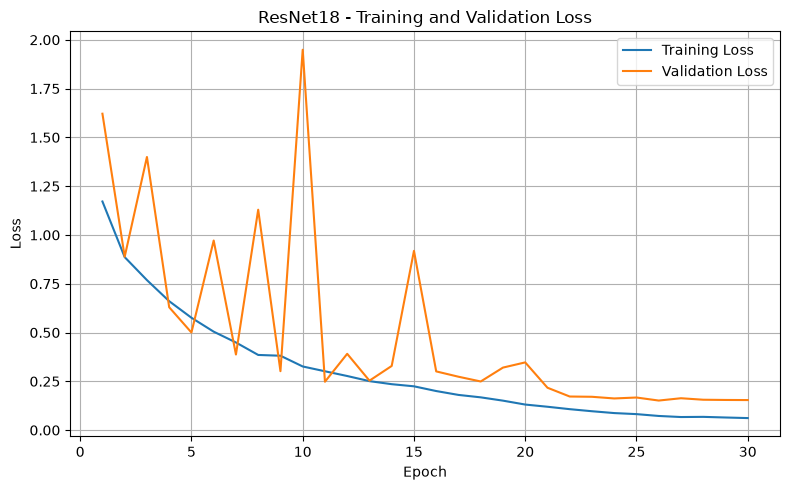

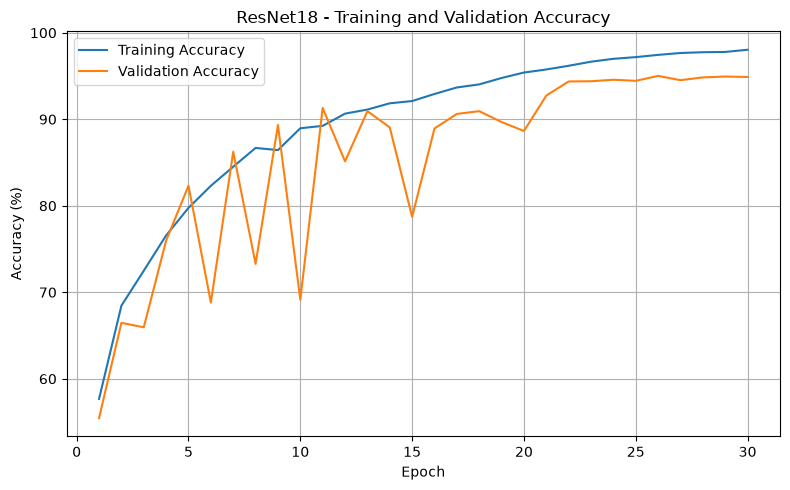

In [28]:
# ============================================================
# RESNET18 — ACCURACY AND LOSS CURVES
# ============================================================

epochs_range = range(
    1,
    len(resnet_history["train_loss"]) + 1
)

# ------------------------------------------------------------
# Loss Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    resnet_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    resnet_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 - Training and Validation Loss")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Accuracy Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    resnet_history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    resnet_history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 - Training and Validation Accuracy")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# TESTING FUNCTION
# ============================================================

def test_model(
    model,
    model_name
):

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"{model_name}_best.pth"
    )

    print("=" * 70)
    print(f"TESTING: {model_name}")
    print("=" * 70)

    # Load best validation checkpoint
    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=DEVICE
        )
    )

    model = model.to(DEVICE)
    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for images, labels in tqdm(
            test_loader,
            desc=f"Testing {model_name}"
        ):

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(images)

            preds = outputs.argmax(
                dim=1
            )

            predictions.extend(
                preds.cpu().numpy()
            )

            targets.extend(
                labels.cpu().numpy()
            )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        targets,
        predictions
    )

    precision = precision_score(
        targets,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        targets,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        targets,
        predictions,
        average="weighted",
        zero_division=0
    )

    # --------------------------------------------------------
    # Results
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print(f"FINAL TEST RESULTS — {model_name}")
    print("=" * 70)

    print(
        f"Accuracy  : {accuracy * 100:.2f}%"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"F1 Score  : {f1:.4f}"
    )

    print("=" * 70)

    # --------------------------------------------------------
    # Classification report
    # --------------------------------------------------------

    print("\nClassification Report:\n")

    print(
        classification_report(
            targets,
            predictions,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0
        )
    )

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "predictions": predictions,
        "targets": targets
    }

In [30]:
# ============================================================
# RESNET18 — FINAL TEST
# ============================================================

resnet_results = test_model(
    resnet_model,
    "ResNet18"
)

TESTING: ResNet18


Testing ResNet18: 100%|██████████| 64/64 [00:06<00:00,  9.99it/s]


FINAL TEST RESULTS — ResNet18
Accuracy  : 95.26%
Precision : 0.9529
Recall    : 0.9526
F1 Score  : 0.9526

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.9406    0.9386    0.9396       472
              Forest     0.9885    0.9729    0.9806       442
HerbaceousVegetation     0.9095    0.9432    0.9260       458
             Highway     0.9634    0.9437    0.9535       391
          Industrial     0.9753    0.9418    0.9583       378
             Pasture     0.9183    0.9398    0.9289       299
       PermanentCrop     0.9247    0.9077    0.9161       379
         Residential     0.9694    0.9844    0.9768       450
               River     0.9501    0.9653    0.9577       375
             SeaLake     0.9827    0.9803    0.9815       406

            accuracy                         0.9526      4050
           macro avg     0.9523    0.9518    0.9519      4050
        weighted avg     0.9529    0.9526    0.9526      405

In [31]:
# ============================================================
# MOBILENETV3-SMALL — TRAINING
# ============================================================

mobilenet_model = create_baseline(
    "MobileNetV3-Small",
    NUM_CLASSES
)

mobilenet_model, mobilenet_history, mobilenet_time = train_model(
    mobilenet_model,
    "MobileNetV3-Small",
    epochs=EPOCHS
)


TRAINING: MobileNetV3-Small
Model device: cuda:0

Epoch 1/30


Train Loss : 1.2776
Train Acc  : 52.93%
Val Loss   : 2.5807
Val Acc    : 7.63%
✓ Best model saved.

Epoch 2/30


Train Loss : 0.9597
Train Acc  : 65.32%
Val Loss   : 1.3294
Val Acc    : 54.32%
✓ Best model saved.

Epoch 3/30


Train Loss : 0.8478
Train Acc  : 69.21%
Val Loss   : 0.8131
Val Acc    : 70.15%
✓ Best model saved.

Epoch 4/30


Train Loss : 0.7737
Train Acc  : 72.31%
Val Loss   : 0.6864
Val Acc    : 76.72%
✓ Best model saved.

Epoch 5/30


...

Train Loss : 0.2306
Train Acc  : 91.69%
Val Loss   : 0.2035
Val Acc    : 92.89%
✓ Best model saved.

Epoch 27/30


Train Loss : 0.2223
Train Acc  : 92.15%
Val Loss   : 0.2063
Val Acc    : 92.64%

Epoch 28/30


Train Loss : 0.2190
Train Acc  : 92.39%
Val Loss   : 0.2011
Val Acc    : 92.79%

Epoch 29/30


Train Loss : 0.2168
Train Acc  : 92.49%
Val Loss   : 0.2012
Val Acc    : 92.69%

Epoch 30/30


Train Loss : 0.2193
Train Acc  : 91.97%
Val Loss   : 0.2017
Val Acc    : 92.67%

MobileNetV3-Small TRAINING COMPLETE
Best Validation Accuracy: 92.89%
Training Time: 41.38 minutes
Final GPU: cuda:0


In [32]:
# ============================================================
# MOBILENETV3-SMALL — FINAL TEST
# ============================================================

mobilenet_results = test_model(
    mobilenet_model,
    "MobileNetV3-Small"
)

print(mobilenet_results)

TESTING: MobileNetV3-Small


Testing MobileNetV3-Small: 100%|██████████| 64/64 [00:07<00:00,  9.13it/s]



FINAL TEST RESULTS — MobileNetV3-Small
Accuracy  : 92.59%
Precision : 0.9259
Recall    : 0.9259
F1 Score  : 0.9258

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.9228    0.9364    0.9295       472
              Forest     0.9771    0.9661    0.9716       442
HerbaceousVegetation     0.8698    0.8603    0.8650       458
             Highway     0.9191    0.9003    0.9096       391
          Industrial     0.9388    0.9339    0.9363       378
             Pasture     0.8921    0.9398    0.9153       299
       PermanentCrop     0.8660    0.8522    0.8590       379
         Residential     0.9564    0.9756    0.9659       450
               River     0.9366    0.9067    0.9214       375
             SeaLake     0.9684    0.9828    0.9756       406

            accuracy                         0.9259      4050
           macro avg     0.9247    0.9254    0.9249      4050
        weighted avg     0.9259    0.9259    0.9258

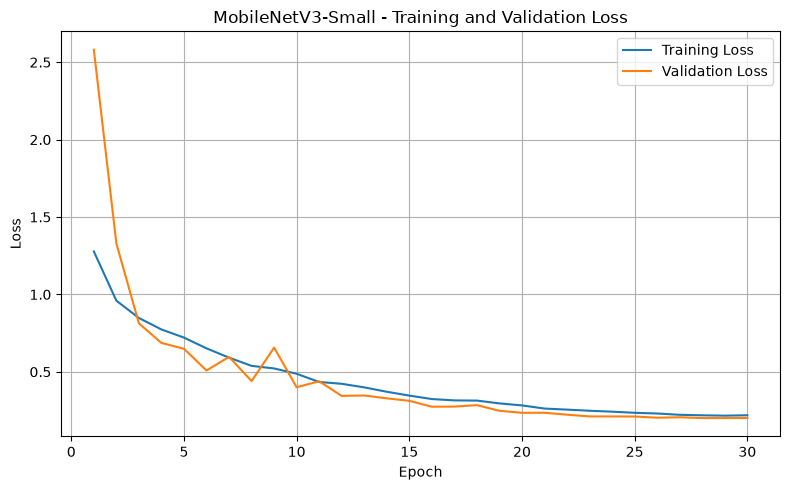

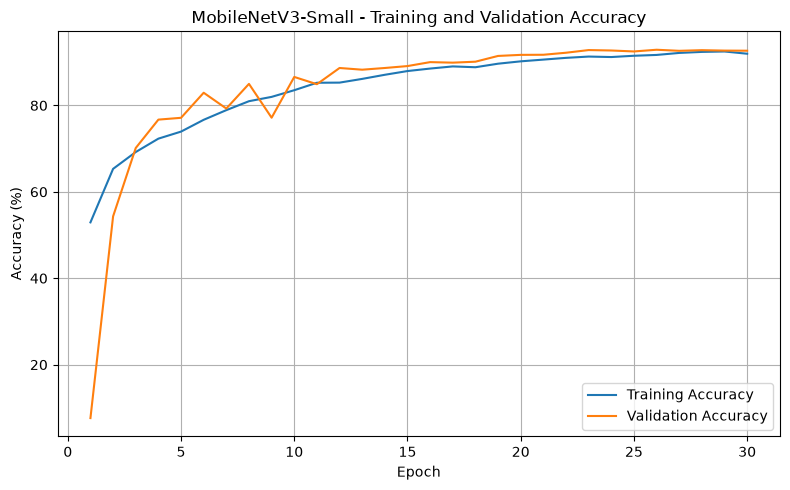

In [33]:
# ============================================================
# MOBILENETV3-SMALL — LOSS CURVE
# ============================================================

epochs_range = range(
    1,
    len(mobilenet_history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    mobilenet_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    mobilenet_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "MobileNetV3-Small - Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()



# ============================================================
# MOBILENETV3-SMALL — ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    mobilenet_history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    mobilenet_history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "MobileNetV3-Small - Training and Validation Accuracy"
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# EFFICIENTNET-B0 — TRAINING
# ============================================================

efficientnet_model = create_baseline(
    "EfficientNet-B0",
    NUM_CLASSES
)

efficientnet_model, efficientnet_history, efficientnet_time = train_model(
    efficientnet_model,
    "EfficientNet-B0",
    epochs=EPOCHS
)


TRAINING: EfficientNet-B0
Model device: cuda:0

Epoch 1/30


Train Loss : 1.3951
Train Acc  : 48.74%
Val Loss   : 0.8650
Val Acc    : 69.60%
✓ Best model saved.

Epoch 2/30


Train Loss : 0.8989
Train Acc  : 67.30%
Val Loss   : 0.6923
Val Acc    : 73.73%
✓ Best model saved.

Epoch 3/30


Train Loss : 0.7609
Train Acc  : 72.84%
Val Loss   : 0.7284
Val Acc    : 74.00%
✓ Best model saved.

Epoch 4/30


Train Loss : 0.6601
Train Acc  : 77.20%
Val Loss   : 0.5566
Val Acc    : 80.47%
✓ Best model saved.

Epoch 5/30


...

Train Loss : 0.1148
Train Acc  : 95.89%
Val Loss   : 0.1465
Val Acc    : 94.99%

Epoch 27/30


Train Loss : 0.1107
Train Acc  : 96.12%
Val Loss   : 0.1367
Val Acc    : 95.43%
✓ Best model saved.

Epoch 28/30


Train Loss : 0.1078
Train Acc  : 96.25%
Val Loss   : 0.1440
Val Acc    : 94.91%

Epoch 29/30


Train Loss : 0.1087
Train Acc  : 96.27%
Val Loss   : 0.1424
Val Acc    : 95.04%

Epoch 30/30


Train Loss : 0.1031
Train Acc  : 96.46%
Val Loss   : 0.1378
Val Acc    : 95.14%

EfficientNet-B0 TRAINING COMPLETE
Best Validation Accuracy: 95.43%
Training Time: 51.20 minutes
Final GPU: cuda:0


In [35]:
# ============================================================
# EFFICIENTNET-B0 — FINAL TEST
# ============================================================

efficientnet_results = test_model(
    efficientnet_model,
    "EfficientNet-B0"
)

print(efficientnet_results)

TESTING: EfficientNet-B0


Testing EfficientNet-B0: 100%|██████████| 64/64 [00:07<00:00,  8.91it/s]



FINAL TEST RESULTS — EfficientNet-B0
Accuracy  : 95.11%
Precision : 0.9514
Recall    : 0.9511
F1 Score  : 0.9512

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.9304    0.9343    0.9323       472
              Forest     0.9954    0.9864    0.9909       442
HerbaceousVegetation     0.8908    0.9258    0.9079       458
             Highway     0.9564    0.9540    0.9552       391
          Industrial     0.9654    0.9603    0.9629       378
             Pasture     0.9379    0.9599    0.9488       299
       PermanentCrop     0.9158    0.8892    0.9023       379
         Residential     0.9821    0.9733    0.9777       450
               River     0.9543    0.9467    0.9505       375
             SeaLake     0.9851    0.9803    0.9827       406

            accuracy                         0.9511      4050
           macro avg     0.9514    0.9510    0.9511      4050
        weighted avg     0.9514    0.9511    0.9512  

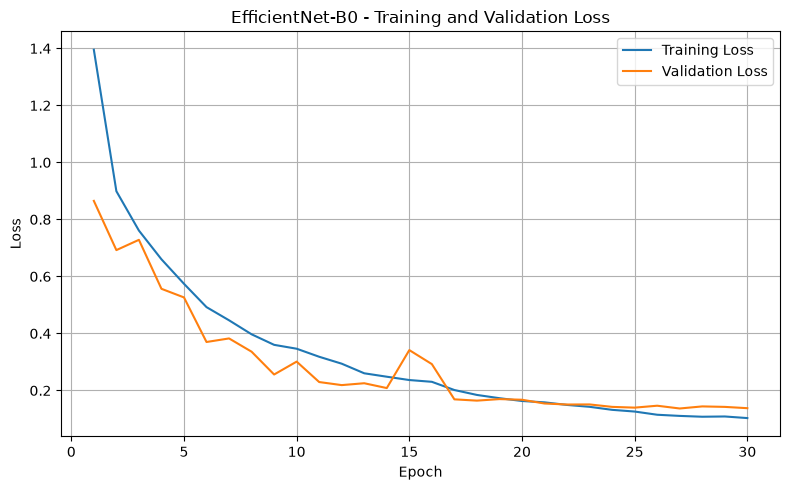

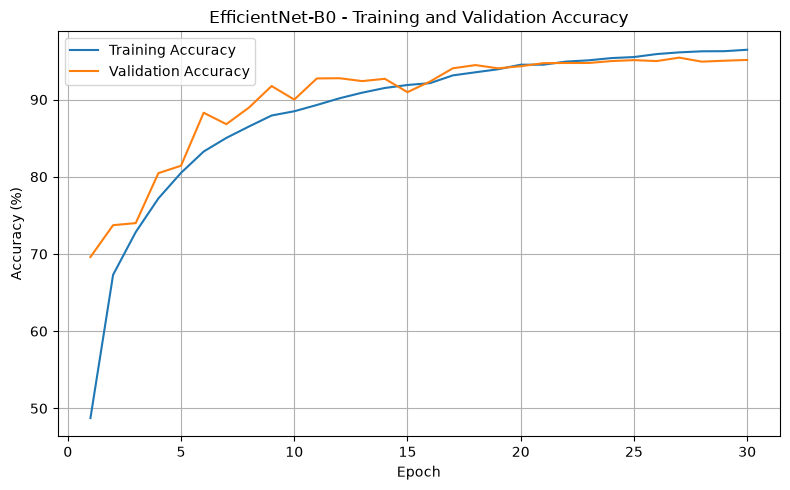

In [36]:
# ============================================================
# EFFICIENTNET-B0 — LOSS CURVE
# ============================================================

epochs_range = range(
    1,
    len(efficientnet_history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    efficientnet_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    efficientnet_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "EfficientNet-B0 - Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


# ============================================================
# EFFICIENTNET-B0 — ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    efficientnet_history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    efficientnet_history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "EfficientNet-B0 - Training and Validation Accuracy"
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# CONVNEXT-TINY — TRAINING
# ============================================================

convnext_model = create_baseline(
    "ConvNeXt-Tiny",
    NUM_CLASSES
)

convnext_model, convnext_history, convnext_time = train_model(
    convnext_model,
    "ConvNeXt-Tiny",
    epochs=EPOCHS
)


TRAINING: ConvNeXt-Tiny
Model device: cuda:0

Epoch 1/30


Train Loss : 1.7834
Train Acc  : 34.71%
Val Loss   : 1.3722
Val Acc    : 49.21%
✓ Best model saved.

Epoch 2/30


Train Loss : 1.3323
Train Acc  : 48.85%
Val Loss   : 1.1326
Val Acc    : 52.96%
✓ Best model saved.

Epoch 3/30


Train Loss : 1.1245
Train Acc  : 57.11%
Val Loss   : 1.0088
Val Acc    : 63.31%
✓ Best model saved.

Epoch 4/30


Train Loss : 1.0115
Train Acc  : 61.67%
Val Loss   : 0.8412
Val Acc    : 69.56%
✓ Best model saved.

Epoch 5/30


...

Train Loss : 0.2122
Train Acc  : 92.59%
Val Loss   : 0.3379
Val Acc    : 88.57%

Epoch 27/30


Train Loss : 0.1997
Train Acc  : 93.15%
Val Loss   : 0.3280
Val Acc    : 88.67%

Epoch 28/30


Train Loss : 0.1951
Train Acc  : 93.05%
Val Loss   : 0.3253
Val Acc    : 88.86%

Epoch 29/30


Train Loss : 0.1909
Train Acc  : 93.40%
Val Loss   : 0.3275
Val Acc    : 88.89%
✓ Best model saved.

Epoch 30/30


Train Loss : 0.1879
Train Acc  : 93.50%
Val Loss   : 0.3270
Val Acc    : 88.89%

ConvNeXt-Tiny TRAINING COMPLETE
Best Validation Accuracy: 88.89%
Training Time: 38.80 minutes
Final GPU: cuda:0


In [38]:
# ============================================================
# CONVNEXT-TINY — FINAL TEST
# ============================================================

convnext_results = test_model(
    convnext_model,
    "ConvNeXt-Tiny"
)

print(convnext_results)

TESTING: ConvNeXt-Tiny


Testing ConvNeXt-Tiny: 100%|██████████| 64/64 [00:07<00:00,  9.05it/s]



FINAL TEST RESULTS — ConvNeXt-Tiny
Accuracy  : 90.10%
Precision : 0.9012
Recall    : 0.9010
F1 Score  : 0.9008

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.8992    0.9068    0.9030       472
              Forest     0.9489    0.9661    0.9574       442
HerbaceousVegetation     0.8697    0.8013    0.8341       458
             Highway     0.8475    0.8389    0.8432       391
          Industrial     0.9339    0.9339    0.9339       378
             Pasture     0.8933    0.8963    0.8948       299
       PermanentCrop     0.7887    0.8470    0.8168       379
         Residential     0.9559    0.9644    0.9602       450
               River     0.8835    0.8693    0.8763       375
             SeaLake     0.9754    0.9778    0.9766       406

            accuracy                         0.9010      4050
           macro avg     0.8996    0.9002    0.8996      4050
        weighted avg     0.9012    0.9010    0.9008    

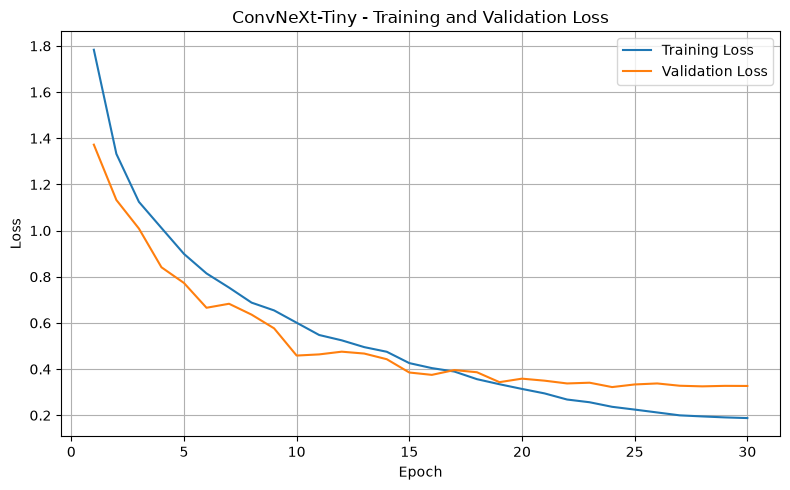

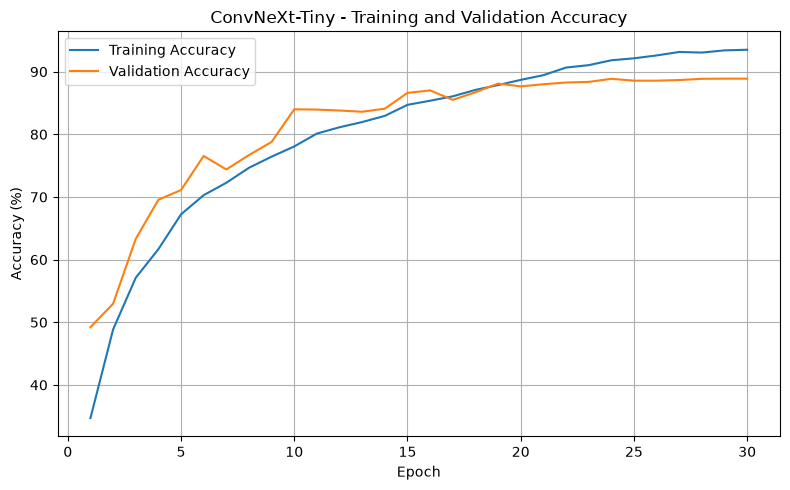

In [39]:
# ============================================================
# CONVNEXT-TINY — LOSS CURVE
# ============================================================

epochs_range = range(
    1,
    len(convnext_history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    convnext_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    convnext_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ConvNeXt-Tiny - Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


# ============================================================
# CONVNEXT-TINY — ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    convnext_history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    convnext_history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "ConvNeXt-Tiny - Training and Validation Accuracy"
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# BASELINE RESULTS TABLE
# ============================================================

baseline_results = pd.DataFrame([
    {
        "Model": "ResNet18",
        "Best Val Accuracy (%)":
            max(resnet_history["val_acc"]),
        "Test Accuracy (%)":
            resnet_results["accuracy"] * 100,
        "Precision":
            resnet_results["precision"],
        "Recall":
            resnet_results["recall"],
        "F1":
            resnet_results["f1"],
        "Training Time (min)":
            resnet_time / 60
    },

    {
        "Model": "MobileNetV3-Small",
        "Best Val Accuracy (%)":
            max(mobilenet_history["val_acc"]),
        "Test Accuracy (%)":
            mobilenet_results["accuracy"] * 100,
        "Precision":
            mobilenet_results["precision"],
        "Recall":
            mobilenet_results["recall"],
        "F1":
            mobilenet_results["f1"],
        "Training Time (min)":
            mobilenet_time / 60
    },

    {
        "Model": "EfficientNet-B0",
        "Best Val Accuracy (%)":
            max(efficientnet_history["val_acc"]),
        "Test Accuracy (%)":
            efficientnet_results["accuracy"] * 100,
        "Precision":
            efficientnet_results["precision"],
        "Recall":
            efficientnet_results["recall"],
        "F1":
            efficientnet_results["f1"],
        "Training Time (min)":
            efficientnet_time / 60
    },

    {
        "Model": "ConvNeXt-Tiny",
        "Best Val Accuracy (%)":
            max(convnext_history["val_acc"]),
        "Test Accuracy (%)":
            convnext_results["accuracy"] * 100,
        "Precision":
            convnext_results["precision"],
        "Recall":
            convnext_results["recall"],
        "F1":
            convnext_results["f1"],
        "Training Time (min)":
            convnext_time / 60
    }
])

baseline_results

,Model,Best Val Accuracy (%),Test Accuracy (%),Precision,Recall,F1,Training Time (min)
0,ResNet18,95.012346,95.259259,0.952920,0.952593,0.952649,32.476154
1,MobileNetV3-Small,92.888889,92.592593,0.925864,0.925926,0.925783,41.383356
2,EfficientNet-B0,95.432099,95.111111,0.951418,0.951111,0.951191,51.199854
3,ConvNeXt-Tiny,88.888889,90.098765,0.901243,0.900988,0.900840,38.799297


In [41]:
# ============================================================
# AFINET — FINAL PRE-TRAINING CHECK
# ============================================================

afinet = AFINet(
    num_classes=NUM_CLASSES
).to(DEVICE)

print("=" * 70)
print("AFINet PRE-TRAINING CHECK")
print("=" * 70)

print(
    "Device:",
    next(afinet.parameters()).device
)

afinet_parameters = sum(
    p.numel()
    for p in afinet.parameters()
    if p.requires_grad
)

print(
    f"Trainable Parameters: "
    f"{afinet_parameters:,}"
)

print(
    f"Parameters (M): "
    f"{afinet_parameters / 1e6:.3f}"
)

# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------

images, labels = next(
    iter(train_loader)
)

images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)

afinet.eval()

with torch.no_grad():

    with torch.amp.autocast(
        device_type="cuda",
        dtype=torch.float16
    ):

        outputs = afinet(images)

print(
    "Input shape :",
    images.shape
)

print(
    "Output shape:",
    outputs.shape
)

print(
    "Output device:",
    outputs.device
)

print(
    "NaN present:",
    torch.isnan(outputs).any().item()
)

print("=" * 70)

AFINet PRE-TRAINING CHECK
Device: cuda:0
Trainable Parameters: 2,979,346
Parameters (M): 2.979
Input shape : torch.Size([64, 3, 64, 64])
Output shape: torch.Size([64, 10])
Output device: cuda:0
NaN present: False


In [42]:
# ============================================================
# AFINET — FINAL MODEL TRAINING
# ============================================================

afinet_model = AFINet(
    num_classes=NUM_CLASSES
).to(DEVICE)

print("=" * 70)
print("AFINet TRAINING")
print("=" * 70)

print(
    "Model device:",
    next(afinet_model.parameters()).device
)

afinet_model, afinet_history, afinet_time = train_model(
    afinet_model,
    "AFINet",
    epochs=EPOCHS
)

AFINet TRAINING
Model device: cuda:0

TRAINING: AFINet
Model device: cuda:0

Epoch 1/30


Train Loss : 0.8324
Train Acc  : 70.21%
Val Loss   : 0.5203
Val Acc    : 82.20%
✓ Best model saved.

Epoch 2/30


Train Loss : 0.4739
Train Acc  : 83.49%
Val Loss   : 0.3499
Val Acc    : 88.27%
✓ Best model saved.

Epoch 3/30


Train Loss : 0.3500
Train Acc  : 88.19%
Val Loss   : 0.2608
Val Acc    : 91.21%
✓ Best model saved.

Epoch 4/30


Train Loss : 0.2600
Train Acc  : 91.03%
Val Loss   : 0.1849
Val Acc    : 93.58%
✓ Best model saved.

Epoch 5/30


...

Train Loss : 0.0142
Train Acc  : 99.60%
Val Loss   : 0.0845
Val Acc    : 97.26%

Epoch 27/30


Train Loss : 0.0134
Train Acc  : 99.58%
Val Loss   : 0.0791
Val Acc    : 97.16%

Epoch 28/30


Train Loss : 0.0128
Train Acc  : 99.60%
Val Loss   : 0.0810
Val Acc    : 96.94%

Epoch 29/30


Train Loss : 0.0123
Train Acc  : 99.65%
Val Loss   : 0.0839
Val Acc    : 96.94%

Epoch 30/30


Train Loss : 0.0109
Train Acc  : 99.70%
Val Loss   : 0.0823
Val Acc    : 97.09%

AFINet TRAINING COMPLETE
Best Validation Accuracy: 97.28%
Training Time: 37.89 minutes
Final GPU: cuda:0


In [43]:
# ============================================================
# AFINET — FINAL TEST
# ============================================================

afinet_results = test_model(
    afinet_model,
    "AFINet"
)

print(afinet_results)

TESTING: AFINet


Testing AFINet: 100%|██████████| 64/64 [00:07<00:00,  8.23it/s]



FINAL TEST RESULTS — AFINet
Accuracy  : 96.89%
Precision : 0.9692
Recall    : 0.9689
F1 Score  : 0.9689

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.9739    0.9492    0.9614       472
              Forest     0.9887    0.9887    0.9887       442
HerbaceousVegetation     0.9593    0.9258    0.9422       458
             Highway     0.9720    0.9770    0.9745       391
          Industrial     0.9786    0.9683    0.9734       378
             Pasture     0.9361    0.9799    0.9575       299
       PermanentCrop     0.9241    0.9631    0.9432       379
         Residential     0.9844    0.9822    0.9833       450
               River     0.9785    0.9707    0.9746       375
             SeaLake     0.9829    0.9926    0.9877       406

            accuracy                         0.9689      4050
           macro avg     0.9678    0.9697    0.9686      4050
        weighted avg     0.9692    0.9689    0.9689      4050


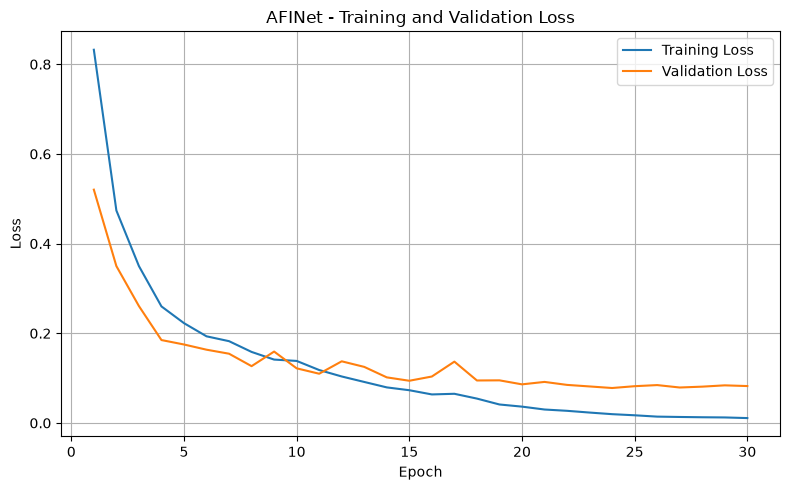

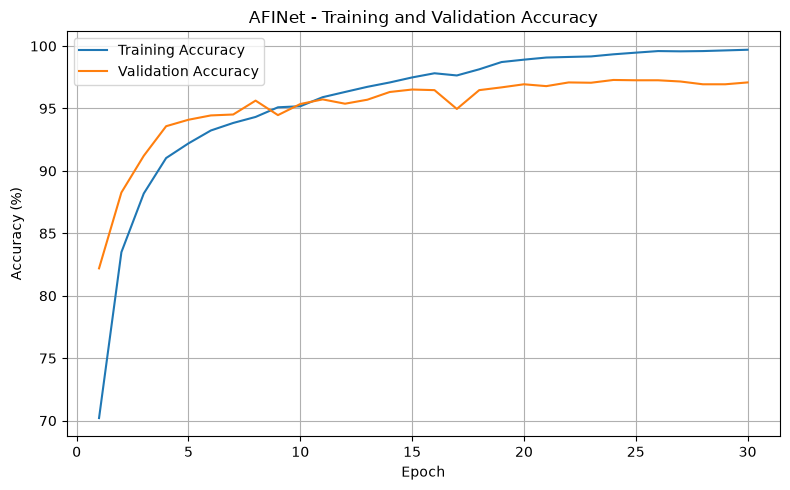

In [44]:
# ============================================================
# AFINET — LOSS CURVE
# ============================================================

epochs_range = range(
    1,
    len(afinet_history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    afinet_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    afinet_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "AFINet - Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


# ============================================================
# AFINET — ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    afinet_history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    afinet_history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "AFINet - Training and Validation Accuracy"
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# COMPLETE MODEL COMPARISON
# ============================================================

all_results = pd.DataFrame([

    {
        "Model": "ResNet18",
        "Parameters (M)": sum(
            p.numel()
            for p in resnet_model.parameters()
        ) / 1e6,
        "Best Val Acc (%)":
            max(resnet_history["val_acc"]),
        "Test Acc (%)":
            resnet_results["accuracy"] * 100,
        "Precision":
            resnet_results["precision"],
        "Recall":
            resnet_results["recall"],
        "F1":
            resnet_results["f1"],
        "Training Time (min)":
            resnet_time / 60
    },

    {
        "Model": "MobileNetV3-Small",
        "Parameters (M)": sum(
            p.numel()
            for p in mobilenet_model.parameters()
        ) / 1e6,
        "Best Val Acc (%)":
            max(mobilenet_history["val_acc"]),
        "Test Acc (%)":
            mobilenet_results["accuracy"] * 100,
        "Precision":
            mobilenet_results["precision"],
        "Recall":
            mobilenet_results["recall"],
        "F1":
            mobilenet_results["f1"],
        "Training Time (min)":
            mobilenet_time / 60
    },

    {
        "Model": "EfficientNet-B0",
        "Parameters (M)": sum(
            p.numel()
            for p in efficientnet_model.parameters()
        ) / 1e6,
        "Best Val Acc (%)":
            max(efficientnet_history["val_acc"]),
        "Test Acc (%)":
            efficientnet_results["accuracy"] * 100,
        "Precision":
            efficientnet_results["precision"],
        "Recall":
            efficientnet_results["recall"],
        "F1":
            efficientnet_results["f1"],
        "Training Time (min)":
            efficientnet_time / 60
    },

    {
        "Model": "ConvNeXt-Tiny",
        "Parameters (M)": sum(
            p.numel()
            for p in convnext_model.parameters()
        ) / 1e6,
        "Best Val Acc (%)":
            max(convnext_history["val_acc"]),
        "Test Acc (%)":
            convnext_results["accuracy"] * 100,
        "Precision":
            convnext_results["precision"],
        "Recall":
            convnext_results["recall"],
        "F1":
            convnext_results["f1"],
        "Training Time (min)":
            convnext_time / 60
    },

    {
        "Model": "AFINet",
        "Parameters (M)": sum(
            p.numel()
            for p in afinet_model.parameters()
        ) / 1e6,
        "Best Val Acc (%)":
            max(afinet_history["val_acc"]),
        "Test Acc (%)":
            afinet_results["accuracy"] * 100,
        "Precision":
            afinet_results["precision"],
        "Recall":
            afinet_results["recall"],
        "F1":
            afinet_results["f1"],
        "Training Time (min)":
            afinet_time / 60
    }
])

all_results

,Model,Parameters (M),Best Val Acc (%),Test Acc (%),Precision,Recall,F1,Training Time (min)
0,ResNet18,11.181642,95.012346,95.259259,0.952920,0.952593,0.952649,32.476154
1,MobileNetV3-Small,1.528106,92.888889,92.592593,0.925864,0.925926,0.925783,41.383356
2,EfficientNet-B0,4.020358,95.432099,95.111111,0.951418,0.951111,0.951191,51.199854
3,ConvNeXt-Tiny,27.827818,88.888889,90.098765,0.901243,0.900988,0.900840,38.799297
4,AFINet,2.979346,97.283951,96.888889,0.969161,0.968889,0.968891,37.894477


In [46]:
# ============================================================
# AFINET IMPROVEMENT OVER BEST BASELINE
# ============================================================

baseline_test_acc = max([
    resnet_results["accuracy"],
    mobilenet_results["accuracy"],
    efficientnet_results["accuracy"],
    convnext_results["accuracy"]
])

afinet_test_acc = afinet_results["accuracy"]

absolute_improvement = (
    afinet_test_acc - baseline_test_acc
) * 100

relative_improvement = (
    (afinet_test_acc - baseline_test_acc)
    / baseline_test_acc
) * 100

print("=" * 60)

print(
    f"Best baseline test accuracy : "
    f"{baseline_test_acc * 100:.2f}%"
)

print(
    f"AFINet test accuracy        : "
    f"{afinet_test_acc * 100:.2f}%"
)

print(
    f"Absolute improvement        : "
    f"{absolute_improvement:.2f} percentage points"
)

print(
    f"Relative improvement        : "
    f"{relative_improvement:.2f}%"
)

print("=" * 60)

Best baseline test accuracy : 95.26%
AFINet test accuracy        : 96.89%
Absolute improvement        : 1.63 percentage points
Relative improvement        : 1.71%


In [47]:
# ============================================================
# EFFICIENCY ANALYSIS — DEPENDENCY
# ============================================================

!pip install thop -q


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
# ============================================================
# EFFICIENCY MEASUREMENT FUNCTION
# ============================================================

from thop import profile
import time
import torch
import pandas as pd
import numpy as np


def calculate_efficiency(
    model,
    model_name,
    test_accuracy,
    training_time
):

    model = model.to(DEVICE)
    model.eval()

    # --------------------------------------------------------
    # Parameters
    # --------------------------------------------------------

    parameters = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    # --------------------------------------------------------
    # FLOPs
    # --------------------------------------------------------

    dummy_input = torch.randn(
        1,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=DEVICE
    )

    with torch.no_grad():

        flops, params_thop = profile(
            model,
            inputs=(dummy_input,),
            verbose=False
        )

    # FLOPs -> Giga FLOPs
    gflops = flops / 1e9

    # --------------------------------------------------------
    # GPU warm-up
    # --------------------------------------------------------

    with torch.no_grad():

        for _ in range(20):
            _ = model(dummy_input)

    torch.cuda.synchronize()

    # --------------------------------------------------------
    # Inference timing
    # --------------------------------------------------------

    repetitions = 100

    start_time = time.perf_counter()

    with torch.no_grad():

        for _ in range(repetitions):
            _ = model(dummy_input)

    torch.cuda.synchronize()

    elapsed = (
        time.perf_counter() - start_time
    )

    inference_time_ms = (
        elapsed / repetitions
    ) * 1000

    # --------------------------------------------------------
    # Throughput
    # --------------------------------------------------------

    throughput = (
        1000 / inference_time_ms
    )

    # --------------------------------------------------------
    # Accuracy per million parameters
    # --------------------------------------------------------

    accuracy_per_million = (
        test_accuracy /
        (parameters / 1e6)
    )

    # --------------------------------------------------------
    # Return
    # --------------------------------------------------------

    return {

        "Model": model_name,

        "Parameters (M)":
            parameters / 1e6,

        "FLOPs (G)":
            gflops,

        "Inference Time (ms)":
            inference_time_ms,

        "Throughput (images/s)":
            throughput,

        "Test Accuracy (%)":
            test_accuracy,

        "Accuracy / M Params":
            accuracy_per_million,

        "Training Time (min)":
            training_time / 60
    }

In [49]:
# ============================================================
# CALCULATE EFFICIENCY FOR ALL MODELS
# ============================================================

efficiency_results = []


# ------------------------------------------------------------
# ResNet18
# ------------------------------------------------------------

efficiency_results.append(
    calculate_efficiency(
        resnet_model,
        "ResNet18",
        resnet_results["accuracy"] * 100,
        resnet_time
    )
)


# ------------------------------------------------------------
# MobileNetV3-Small
# ------------------------------------------------------------

efficiency_results.append(
    calculate_efficiency(
        mobilenet_model,
        "MobileNetV3-Small",
        mobilenet_results["accuracy"] * 100,
        mobilenet_time
    )
)


# ------------------------------------------------------------
# EfficientNet-B0
# ------------------------------------------------------------

efficiency_results.append(
    calculate_efficiency(
        efficientnet_model,
        "EfficientNet-B0",
        efficientnet_results["accuracy"] * 100,
        efficientnet_time
    )
)


# ------------------------------------------------------------
# ConvNeXt-Tiny
# ------------------------------------------------------------

efficiency_results.append(
    calculate_efficiency(
        convnext_model,
        "ConvNeXt-Tiny",
        convnext_results["accuracy"] * 100,
        convnext_time
    )
)


# ------------------------------------------------------------
# AFINet
# ------------------------------------------------------------

efficiency_results.append(
    calculate_efficiency(
        afinet_model,
        "AFINet",
        afinet_results["accuracy"] * 100,
        afinet_time
    )
)

In [50]:
# ============================================================
# FINAL EFFICIENCY TABLE
# ============================================================

efficiency_table = pd.DataFrame(
    efficiency_results
)

# Round for publication readability

efficiency_table = efficiency_table.round({

    "Parameters (M)": 3,

    "FLOPs (G)": 3,

    "Inference Time (ms)": 3,

    "Throughput (images/s)": 2,

    "Test Accuracy (%)": 2,

    "Accuracy / M Params": 3,

    "Training Time (min)": 2
})

efficiency_table

,Model,Parameters (M),FLOPs (G),Inference Time (ms),Throughput (images/s),Test Accuracy (%),Accuracy / M Params,Training Time (min)
0,ResNet18,11.182,0.149,8.945,111.80,95.26,8.519,32.48
1,MobileNetV3-Small,1.528,0.006,22.073,45.30,92.59,60.593,41.38
2,EfficientNet-B0,4.020,0.034,34.673,28.84,95.11,23.657,51.20
3,ConvNeXt-Tiny,27.828,0.364,20.411,48.99,90.10,3.238,38.80
4,AFINet,2.979,0.494,23.928,41.79,96.89,32.520,37.89


In [52]:
# ============================================================
# SORT BY TEST ACCURACY
# ============================================================

accuracy_table = efficiency_table.sort_values(
    by="Test Accuracy (%)",
    ascending=True
).reset_index(drop=True)

accuracy_table

,Model,Parameters (M),FLOPs (G),Inference Time (ms),Throughput (images/s),Test Accuracy (%),Accuracy / M Params,Training Time (min)
0,ConvNeXt-Tiny,27.828,0.364,20.411,48.99,90.10,3.238,38.80
1,MobileNetV3-Small,1.528,0.006,22.073,45.30,92.59,60.593,41.38
2,EfficientNet-B0,4.020,0.034,34.673,28.84,95.11,23.657,51.20
3,ResNet18,11.182,0.149,8.945,111.80,95.26,8.519,32.48
4,AFINet,2.979,0.494,23.928,41.79,96.89,32.520,37.89


FINAL TEST EVALUATION
Device: cuda

Testing ResNet18...

Testing MobileNetV3-Small...

Testing EfficientNet-B0...

Testing ConvNeXt-Tiny...

Testing AFINet...


FINAL MODEL COMPARISON


,Model,Test Loss,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Weighted Precision (%),Weighted Recall (%),Weighted F1 (%),Parameters (M)
0,ResNet18,0.1507,95.2593,95.2300,95.1770,95.1926,95.2932,95.2593,95.2654,11.1816
1,MobileNetV3-Small,0.2183,92.5926,92.4704,92.5384,92.4925,92.5835,92.5926,92.5776,1.5281
2,EfficientNet-B0,0.1311,95.1111,95.1359,95.1014,95.1113,95.1418,95.1111,95.1191,4.0204
3,ConvNeXt-Tiny,0.3010,90.1235,89.9826,90.0495,89.9884,90.1527,90.1235,90.1091,27.8278
4,AFINet,0.0958,96.9136,96.8076,96.9980,96.8883,96.9410,96.9136,96.9137,2.9793




PUBLICATION TABLE


,Model,Parameters (M),Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Weighted F1 (%)
0,ResNet18,11.18,95.26,95.23,95.18,95.19,95.27
1,MobileNetV3-Small,1.53,92.59,92.47,92.54,92.49,92.58
2,EfficientNet-B0,4.02,95.11,95.14,95.10,95.11,95.12
3,ConvNeXt-Tiny,27.83,90.12,89.98,90.05,89.99,90.11
4,AFINet,2.98,96.91,96.81,97.00,96.89,96.91




AFINET CLASS-WISE PERFORMANCE


,Class,Precision (%),Recall (%),F1-score (%),Support
0,AnnualCrop,97.39,94.92,96.14,472
1,Forest,99.09,98.87,98.98,442
2,HerbaceousVegetation,95.93,92.58,94.22,458
3,Highway,97.20,97.70,97.45,391
4,Industrial,97.86,96.83,97.34,378
5,Pasture,93.61,97.99,95.75,299
6,PermanentCrop,92.41,96.31,94.32,379
7,Residential,98.44,98.22,98.33,450
8,River,97.85,97.07,97.46,375
9,SeaLake,98.30,99.51,98.90,406


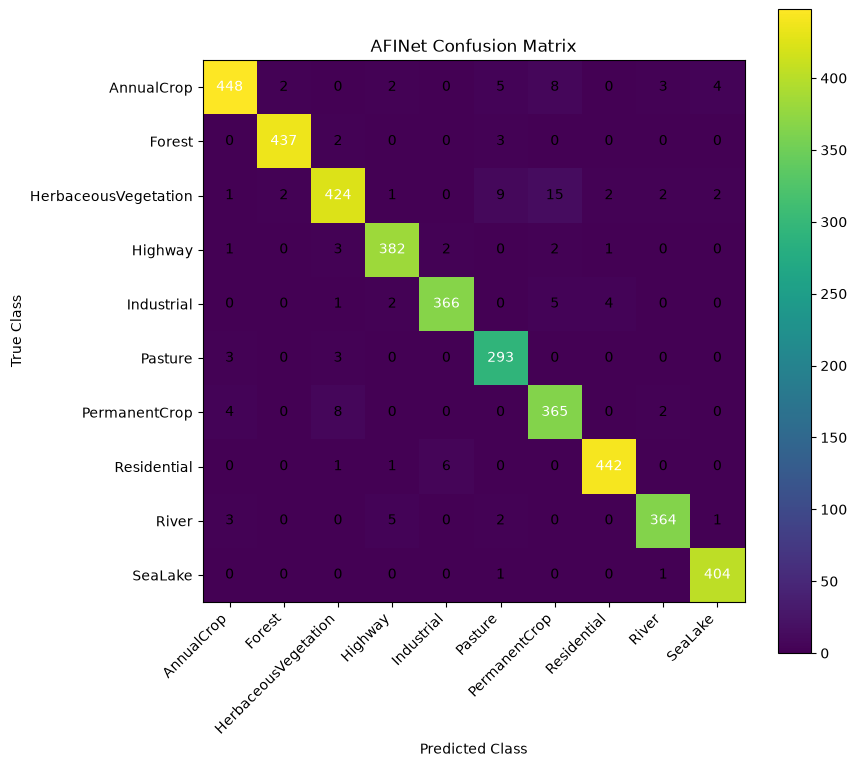



BEST TEST MODEL
Model          : AFINet
Test Accuracy  : 96.91%


AFINET IMPROVEMENT
AFINet Accuracy       : 96.91%
Best Baseline         : ResNet18
Baseline Accuracy     : 95.26%
Absolute Improvement  : 1.65 percentage points


In [54]:
# ============================================================
# FINAL RESULTS EVALUATION — ALL 5 MODELS
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80)
print("FINAL TEST EVALUATION")
print("=" * 80)
print("Device:", device)


# ============================================================
# 1. MODEL DICTIONARY
# ============================================================
# IMPORTANT:
# Use the model variables that already exist in your notebook.

models = {
    "ResNet18": resnet_model,
    "MobileNetV3-Small": mobilenet_model,
    "EfficientNet-B0": efficientnet_model,
    "ConvNeXt-Tiny": convnext_model,
    "AFINet": afinet_model
}


# ============================================================
# 2. CLASS NAMES
# ============================================================

class_names = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]


# ============================================================
# 3. TEST FUNCTION
# ============================================================

def evaluate_model(model, model_name):

    model = model.to(device)
    model.eval()

    all_predictions = []
    all_targets = []

    total_loss = 0.0
    total_samples = 0

    criterion = nn.CrossEntropyLoss()

    print(f"\nTesting {model_name}...")

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += (
                loss.item() * labels.size(0)
            )

            total_samples += labels.size(0)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_targets.extend(
                labels.cpu().numpy()
            )

    # --------------------------------------------------------
    # Convert to numpy
    # --------------------------------------------------------

    y_true = np.array(all_targets)
    y_pred = np.array(all_predictions)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    test_loss = total_loss / total_samples

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_precision, macro_recall, macro_f1, _ = \
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

    weighted_precision, weighted_recall, weighted_f1, _ = \
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

    # --------------------------------------------------------
    # Parameters
    # --------------------------------------------------------

    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    # --------------------------------------------------------
    # Classification report
    # --------------------------------------------------------

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    # --------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    results = {

        "Model": model_name,

        "Test Loss": test_loss,

        "Accuracy (%)":
            accuracy * 100,

        "Macro Precision (%)":
            macro_precision * 100,

        "Macro Recall (%)":
            macro_recall * 100,

        "Macro F1 (%)":
            macro_f1 * 100,

        "Weighted Precision (%)":
            weighted_precision * 100,

        "Weighted Recall (%)":
            weighted_recall * 100,

        "Weighted F1 (%)":
            weighted_f1 * 100,

        "Parameters (M)":
            trainable_params / 1e6
    }

    return (
        results,
        report,
        cm,
        y_true,
        y_pred
    )


# ============================================================
# 4. EVALUATE ALL MODELS
# ============================================================

all_results = []
all_reports = {}
all_confusion_matrices = {}
all_predictions = {}


for model_name, model in models.items():

    results, report, cm, y_true, y_pred = \
        evaluate_model(
            model,
            model_name
        )

    all_results.append(results)

    all_reports[model_name] = report

    all_confusion_matrices[model_name] = cm

    all_predictions[model_name] = (
        y_true,
        y_pred
    )


# ============================================================
# 5. MAIN COMPARISON TABLE
# ============================================================

results_table = pd.DataFrame(
    all_results
)

results_table = results_table.round(4)


print("\n")
print("=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)

display(
    results_table
)


# ============================================================
# 6. PUBLICATION-STYLE COMPARISON TABLE
# ============================================================

publication_table = results_table[
    [
        "Model",
        "Parameters (M)",
        "Accuracy (%)",
        "Macro Precision (%)",
        "Macro Recall (%)",
        "Macro F1 (%)",
        "Weighted F1 (%)"
    ]
].copy()

publication_table = publication_table.round(2)

print("\n")
print("=" * 100)
print("PUBLICATION TABLE")
print("=" * 100)

display(publication_table)


# ============================================================
# 7. AFINET CLASS-WISE RESULTS
# ============================================================

afinet_report = all_reports["AFINet"]

classwise_rows = []

for class_name in class_names:

    classwise_rows.append({

        "Class": class_name,

        "Precision (%)":
            afinet_report[class_name]["precision"] * 100,

        "Recall (%)":
            afinet_report[class_name]["recall"] * 100,

        "F1-score (%)":
            afinet_report[class_name]["f1-score"] * 100,

        "Support":
            int(afinet_report[class_name]["support"])
    })


afinet_classwise = pd.DataFrame(
    classwise_rows
)

afinet_classwise = afinet_classwise.round(2)

print("\n")
print("=" * 100)
print("AFINET CLASS-WISE PERFORMANCE")
print("=" * 100)

display(afinet_classwise)


# ============================================================
# 8. AFINET CONFUSION MATRIX
# ============================================================

afinet_cm = all_confusion_matrices["AFINet"]

plt.figure(figsize=(9, 8))

plt.imshow(
    afinet_cm,
    interpolation="nearest"
)

plt.title(
    "AFINet Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

# Add numbers
threshold = afinet_cm.max() / 2

for i in range(afinet_cm.shape[0]):

    for j in range(afinet_cm.shape[1]):

        plt.text(
            j,
            i,
            str(afinet_cm[i, j]),
            ha="center",
            va="center",
            color="white"
            if afinet_cm[i, j] > threshold
            else "black"
        )

plt.tight_layout()

plt.show()


# ============================================================
# 9. BEST MODEL
# ============================================================

best_idx = results_table[
    "Accuracy (%)"
].idxmax()

best_model = results_table.loc[
    best_idx,
    "Model"
]

best_accuracy = results_table.loc[
    best_idx,
    "Accuracy (%)"
]

print("\n")
print("=" * 80)
print("BEST TEST MODEL")
print("=" * 80)

print(
    f"Model          : {best_model}"
)

print(
    f"Test Accuracy  : {best_accuracy:.2f}%"
)

print("=" * 80)


# ============================================================
# 10. AFINET IMPROVEMENT OVER BEST BASELINE
# ============================================================

baseline_table = results_table[
    results_table["Model"] != "AFINet"
]

best_baseline_idx = baseline_table[
    "Accuracy (%)"
].idxmax()

best_baseline_name = baseline_table.loc[
    best_baseline_idx,
    "Model"
]

best_baseline_accuracy = baseline_table.loc[
    best_baseline_idx,
    "Accuracy (%)"
]

afinet_accuracy = results_table.loc[
    results_table["Model"] == "AFINet",
    "Accuracy (%)"
].iloc[0]

improvement = (
    afinet_accuracy -
    best_baseline_accuracy
)

print("\n")
print("=" * 80)
print("AFINET IMPROVEMENT")
print("=" * 80)

print(
    f"AFINet Accuracy       : {afinet_accuracy:.2f}%"
)

print(
    f"Best Baseline         : {best_baseline_name}"
)

print(
    f"Baseline Accuracy     : {best_baseline_accuracy:.2f}%"
)

print(
    f"Absolute Improvement  : {improvement:.2f} percentage points"
)

print("=" * 80)